In [ ]:
# 1. 필수 라이브러리 및 한글 폰트 설치

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq
!pip install -q transformers soynlp emoji

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 29.2 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
from wordcloud import WordCloud

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
# 대신 PyTorch의 표준 옵티마이저를 사용합니다.
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [ ]:
# 한글 폰트 설정
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 환경 세팅 완료: {device} 사용 중")

✅ 환경 세팅 완료: cuda 사용 중


In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/DS_8th/08_딥러닝 알아보기/60일차_3 18(수)/data/'

In [ ]:
# # --- 2. 데이터 로드 및 통합 (핵심 변경 포인트) ---
# print("🚀 데이터 로드 및 통합 중...")
# # 1) 원본 4개 클래스 데이터 (3,846개)
# train_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))

# # 2) [추가] 일반 대화 데이터 (500개)
# # 주의: normal_conversation.csv의 컬럼명이 'idx', 'class', 'conversation'인지 확인하세요.
# normal_df = pd.read_csv(os.path.join(DATA_PATH, 'normal_conversation.csv'))

# # 3) 데이터 통합
# # normal_df의 idx가 중복되지 않도록 train_df의 마지막 idx 이후로 재설정합니다.
# if 'idx' in normal_df.columns:
#     max_idx = train_df['idx'].max()
#     normal_df['idx'] = range(max_idx + 1, max_idx + 1 + len(normal_df))

# total_df = pd.concat([train_df, normal_df], ignore_index=True)
# print(f"✅ 통합 완료! 총 데이터: {len(total_df)}개")

In [ ]:
def augment_and_merge_data(data_path):
    # 1. 원본 데이터 로드 (4,346개 = 원본 + Normal)
    train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
    normal_df = pd.read_csv(os.path.join(data_path, 'normal_conversation.csv'))

    # 2. [핵심] 기존 증강 데이터 로드 (3년 전 1.5만 개)
    # 파일명이 'train_aug.csv'가 맞는지 확인해주세요!
    try:
        aug_df = pd.read_csv(os.path.join(data_path, 'train_aug.csv'))
        print(f"📂 기존 증강 데이터 로드 완료: {len(aug_df)}개")
    except FileNotFoundError:
        print("⚠️ train_aug.csv를 찾을 수 없습니다. 원본+Normal로만 진행합니다.")
        aug_df = pd.DataFrame()

    # 3. 레이블 통합 관리 (이미지 가이드 표준)
    # 0:갈취, 1:기타, 2:직장, 3:협박, 4:일반
    label_map = {
        '갈취 대화': 0, '기타 괴롭힘 대화': 1, '직장 내 괴롭힘 대화': 2,
        '협박 대화': 3, '일반 대화': 4
    }

    # 각 데이터셋 레이블 매핑
    for df in [train_df, normal_df, aug_df]:
        if not df.empty:
            df['label'] = df['class'].map(label_map)

    # 4. 데이터 합치기 (Concat)
    # 원본(3.8k) + 일반(0.5k) + 증강(15k) = 약 2만 개
    total_df = pd.concat([train_df, normal_df, aug_df], ignore_index=True)

    # 결측치 제거 및 텍스트 정리
    total_df = total_df.dropna(subset=['conversation', 'label'])
    total_df['label'] = total_df['label'].astype(int)

    print(f"✅ 최종 통합 데이터셋 규모: {len(total_df)}개")
    print(total_df['label'].value_counts().sort_index())

    return total_df

In [ ]:
# 1. 데이터 통합 실행
total_df = augment_and_merge_data(DATA_PATH)

📂 기존 증강 데이터 로드 완료: 15800개
✅ 최종 통합 데이터셋 규모: 21016개
label
0    4906
1    5469
2    4894
3    4481
4    1266
Name: count, dtype: int64


In [ ]:
# 1.1 클래스 분포 시각화 (도표 + 퍼센트)

/tmp/ipykernel_11987/3011296388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE 

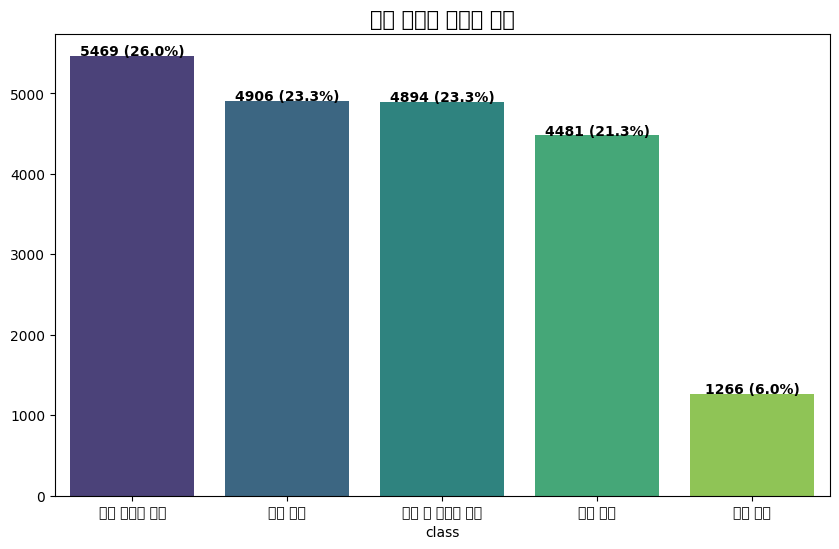

In [ ]:
plt.figure(figsize=(10, 6))
counts = total_df['class'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, f"{v} ({v/len(total_df)*100:.1f}%)", ha='center', fontweight='bold')
plt.title('대화 유형별 클래스 분포', fontsize=15)
plt.show()

In [ ]:
# 1.2 문장 길이 분석 (토큰화 전 기준)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

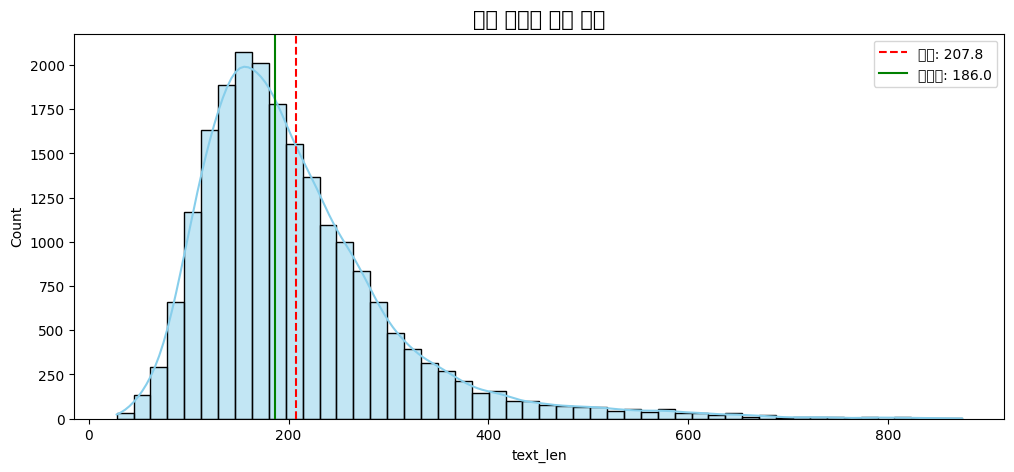

In [ ]:
total_df['text_len'] = total_df['conversation'].apply(len)
plt.figure(figsize=(12, 5))
sns.histplot(total_df['text_len'], bins=50, kde=True, color='skyblue')
plt.axvline(total_df['text_len'].mean(), color='red', linestyle='--', label=f"평균: {total_df['text_len'].mean():.1f}")
plt.axvline(total_df['text_len'].median(), color='green', linestyle='-', label=f"중앙값: {total_df['text_len'].median():.1f}")
plt.title('대화 텍스트 길이 분포', fontsize=15)
plt.legend()
plt.show()

In [ ]:
from soynlp.normalizer import repeat_normalize
import emoji

In [ ]:
def clean_text(text):
    # 이모지 제거 및 텍스트 정규화
    text = emoji.replace_emoji(text, replace='')
    text = repeat_normalize(text, num_repeats=2)
    # 특수문자 중 감정을 나타내는 ?, !, ~는 보존하고 나머지는 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9?!~ ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

In [ ]:
total_df['cleaned'] = total_df['conversation'].apply(clean_text)

In [ ]:
# 샘플 500개에 대해 실제 토큰 길이 계산
# sample_texts = total_df['cleaned'].sample(min(500, len(total_df))).values
# token_lens = []

# for txt in sample_texts:
#     tokens = tokenizer.encode(txt, max_length=512, truncation=True)
#     token_lens.append(len(tokens))

# plt.figure(figsize=(10, 6))
# sns.histplot(token_lens, color='purple', kde=True)
# plt.axvline(x=256, color='red', linestyle='--', label='Current MAX_LEN (256)')
# plt.title('대화 데이터 토큰 길이 분포 분석', fontsize=15)
# plt.xlabel('토큰 개수')
# plt.ylabel('빈도수')
# plt.legend()
# plt.show()

# [인사이트] 256을 넘어서는 데이터가 많다면 MAX_LEN을 더 늘려야 정보 손실이 없습니다.

In [ ]:
# Label Encoding

In [ ]:
label_dict = {label: i for i, label in enumerate(total_df['class'].unique())}
inv_label_dict = {i: label for label, i in label_dict.items()}
total_df['label'] = total_df['class'].map(label_dict)

In [ ]:
# --- 3. [초중요] 레이블 매핑 (5-Class 표준 준수) ---
# 이미지와 가이드 코드에 맞춘 '가나다순' 표준 매핑입니다.
official_label_map = {
    '갈취 대화': 0,
    '기타 괴롭힘 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '협박 대화': 3,
    '일반 대화': 4 # normal_conversation.csv의 class 컬럼값과 맞추세요.
}

# 역매핑 (나중에 추론용)
inv_label_map = {v: k for k, v in official_label_map.items()}

# 데이터프레임에 적용
total_df['label'] = total_df['class'].map(official_label_map)

# 매핑 확인 (0.226 방지용 팩트 체크)
print("\n📊 최종 5-Class 레이블 분포:")
print(total_df['label'].value_counts().sort_index())
print("-" * 30)
for i in range(5):
    print(f"{i} : {inv_label_map[i]}")


📊 최종 5-Class 레이블 분포:
label
0    4906
1    5469
2    4894
3    4481
4    1266
Name: count, dtype: int64
------------------------------
0 : 갈취 대화
1 : 기타 괴롭힘 대화
2 : 직장 내 괴롭힘 대화
3 : 협박 대화
4 : 일반 대화


In [ ]:
# --- 4. 텍스트 전처리 (KLUE-BERT용 최소 전처리) ---
def clean_text(text):
    if not isinstance(text, str): return ""
    # 한글, 영문, 숫자, 필수 문장부호만 남김
    text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?]', ' ', text)
    # 중복 공백 제거
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

print("\n📝 텍스트 전처리 중...")
total_df['cleaned_conversation'] = total_df['conversation'].apply(clean_text)
texts = total_df['cleaned_conversation'].values
labels = total_df['label'].values


📝 텍스트 전처리 중...


In [ ]:
# 데이터셋 분리

In [ ]:
# --- 5. 데이터셋 분할 (Stratified 적용) ---
X_train, X_val, y_train, y_val = train_test_split(
    total_df['cleaned'].values,
    total_df['label'].values,
    test_size=0.1, # 데이터가 많아졌으므로 10%만 검증셋으로 써도 충분합니다.
    random_state=42,
    stratify=total_df['label'].values
)
print(f"\n데이터 분할 완료: Train {len(X_train)}, Val {len(X_val)}")


데이터 분할 완료: Train 18914, Val 2102


In [ ]:
# PyTorch Dataset 정의

In [ ]:
class DKTCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # [수정 포인트] .encode_plus(...) 대신 tokenizer(...)로 직접 호출
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report
import torch
import numpy as np
from tqdm.auto import tqdm

In [ ]:
# 1. 하이퍼파라미터 및 모델 설정
MODEL_NAME = "klue/bert-base"
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 3

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
# 2. 데이터로더 생성 (앞서 통합한 X_train, y_train, X_val, y_val 사용)
train_loader = DataLoader(DKTCDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(DKTCDataset(X_val, y_val, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

In [ ]:
# [핵심] num_labels를 5로 변경!
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5).to(device)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [ ]:
# 2. Optimizer 설정: weight_decay를 0.01에서 0.1로 높여 모델의 복잡도를 제어합니다.
optimizer = AdamW(
    model.parameters(),
    lr=1e-5,           # 2e-5에서 1e-5로 하향 (더 정밀한 학습)
    weight_decay=0.1   # 0.01에서 0.1로 상향 (강력한 규제 적용)
)

In [ ]:
# 3. Scheduler 설정: 그대로 유지하되 EPOCHS가 3으로 줄어든 것을 반영합니다.
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) * 0.1,
    num_training_steps=len(train_loader) * EPOCHS
)

In [ ]:
# 학습 로그 저장용
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

In [ ]:
def train():
    best_f1 = 0
    # 클래스 이름 정의 (리포트 출력용)
    target_names = ['갈취', '기타', '직장', '협박', '일반']

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
            optimizer.zero_grad()
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, preds, targets = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                inputs = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**inputs)
                val_loss += outputs.loss.item()
                logits = outputs.logits.cpu().numpy()
                preds.extend(np.argmax(logits, axis=1))
                targets.extend(inputs['labels'].cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        current_f1 = f1_score(targets, preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(current_f1)

        print(f"\n✅ Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Macro F1 {current_f1:.4f}")

        # 상세 보고서 출력 (어떤 클래스가 약한지 파악)
        print(classification_report(targets, preds, target_names=target_names))

        if current_f1 > best_f1:
            best_f1 = current_f1
            torch.save(model.state_dict(), 'best_dktc_model_5class.pt')
            print("🥇 Best Model Saved! (Score Improved)")

In [ ]:
train()

Epoch 1 Train:   0%|          | 0/1183 [00:00<?, ?it/s]


✅ Epoch 1: Train Loss 0.3342 | Val Loss 0.0964 | Macro F1 0.9785
              precision    recall  f1-score   support

          갈취       0.97      0.97      0.97       491
          기타       0.98      0.97      0.97       547
          직장       1.00      0.98      0.99       489
          협박       0.95      0.98      0.97       448
          일반       1.00      0.98      0.99       127

    accuracy                           0.98      2102
   macro avg       0.98      0.98      0.98      2102
weighted avg       0.98      0.98      0.98      2102

🥇 Best Model Saved! (Score Improved)


Epoch 2 Train:   0%|          | 0/1183 [00:00<?, ?it/s]


✅ Epoch 2: Train Loss 0.0426 | Val Loss 0.0529 | Macro F1 0.9920
              precision    recall  f1-score   support

          갈취       0.99      0.99      0.99       491
          기타       0.99      0.99      0.99       547
          직장       1.00      1.00      1.00       489
          협박       0.98      0.99      0.99       448
          일반       1.00      0.99      1.00       127

    accuracy                           0.99      2102
   macro avg       0.99      0.99      0.99      2102
weighted avg       0.99      0.99      0.99      2102

🥇 Best Model Saved! (Score Improved)


Epoch 3 Train:   0%|          | 0/1183 [00:00<?, ?it/s]


✅ Epoch 3: Train Loss 0.0175 | Val Loss 0.0486 | Macro F1 0.9921
              precision    recall  f1-score   support

          갈취       0.99      0.99      0.99       491
          기타       0.99      0.99      0.99       547
          직장       1.00      1.00      1.00       489
          협박       0.98      0.99      0.99       448
          일반       1.00      0.99      1.00       127

    accuracy                           0.99      2102
   macro avg       0.99      0.99      0.99      2102
weighted avg       0.99      0.99      0.99      2102

🥇 Best Model Saved! (Score Improved)


In [ ]:
# 4.1 학습 결과 시각화

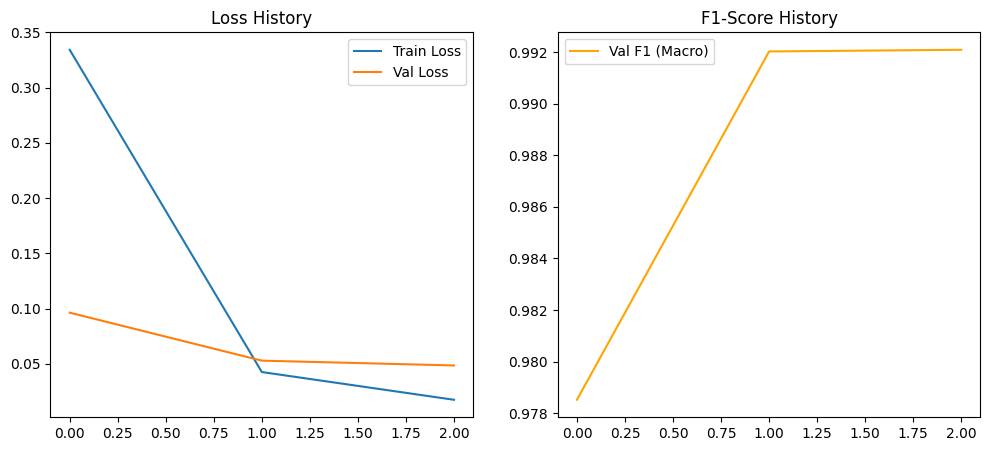

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_f1'], label='Val F1 (Macro)', color='orange')
plt.title('F1-Score History')
plt.legend()
plt.show()

In [ ]:
# 4.2 Confusion Matrix 상세 분석

In [ ]:
model.load_state_dict(torch.load('best_dktc_model_5class.pt'))
model.eval()
preds, targets = [], []
with torch.no_grad():
    for batch in val_loader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        preds.extend(np.argmax(outputs.logits.cpu().numpy(), axis=1))
        targets.extend(inputs['labels'].cpu().numpy())

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

[상세 평가 보고서]
              precision    recall  f1-score   support

       협박 대화       0.99      0.99      0.99       491
   기타 괴롭힘 대화       0.99      0.99      0.99       547
       갈취 대화       1.00      1.00      1.00       489
 직장 내 괴롭힘 대화       0.98      0.99      0.99       448
       일반 대화       1.00      0.99      1.00       127

    accuracy                           0.99      2102
   macro avg       0.99      0.99      0.99      2102
weighted avg       0.99      0.99      0.99      2102



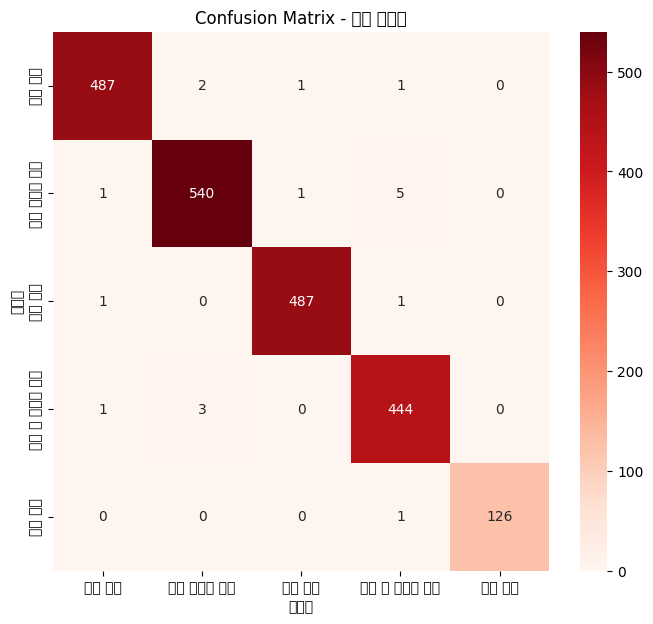

In [ ]:
print("[상세 평가 보고서]")
print(classification_report(targets, preds, target_names=list(label_dict.keys())))

cm = confusion_matrix(targets, preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=list(label_dict.keys()), yticklabels=list(label_dict.keys()))
plt.title('Confusion Matrix - 오답 분석용')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.show()

In [ ]:
import pandas as pd
import torch
import numpy as np
from tqdm.auto import tqdm

def generate_final_victory_submission(test_file_path, model_path, output_name='submission_final_victory.csv'):
    # 1. 모델 로드 (5개 레이블로 학습된 최신 모델)
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    # 2. 테스트 데이터 로드
    test_df = pd.read_csv(test_file_path)

    # 3. [핵심] 5-Class 모델 출력 -> 리더보드 공식 번호로 번역
    # 우리 모델 학습 순서 (0:갈취, 1:기타, 2:직장, 3:협박, 4:일반)
    # 리더보드 정답 번호 (0:협박, 1:갈취, 2:직장, 3:기타, 4:일반)

    translation_map = {
        0: 1, # 모델 '갈취'(0) -> 리더보드 '갈취'(1)
        1: 3, # 모델 '기타'(1) -> 리더보드 '기타'(3)
        2: 2, # 모델 '직장'(2) -> 리더보드 '직장'(2)
        3: 0, # 모델 '협박'(3) -> 리더보드 '협박'(0)
        4: 4  # 모델 '일반'(4) -> 리더보드 '일반'(4)
    }

    final_preds = []
    with torch.no_grad():
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="🏆 최종 점수 복구 중"):
            text = clean_text(row['conversation'])
            inputs = tokenizer(text, return_tensors='pt', truncation=True,
                               max_length=MAX_LEN, padding='max_length').to(device)

            outputs = model(**inputs)
            # 모델의 예측값 (0~4)
            model_pred = torch.argmax(outputs.logits, dim=1).item()

            # 리더보드 번호로 번역
            official_idx = translation_map[model_pred]
            final_preds.append(official_idx)

    # 4. 제출 파일 생성
    submission = pd.DataFrame({
        'idx': test_df['idx'],
        'class': final_preds
    })

    submission.to_csv(output_name, index=False)
    print(f"✨ 0.89+ 고지 점령용 파일 생성 완료: {output_name}")
    print(submission['class'].value_counts().sort_index())

# 실행 (반드시 5개 클래스로 학습된 최신 모델 파일을 넣으세요!)
generate_final_victory_submission(os.path.join(DATA_PATH, 'test.csv'), 'best_dktc_model_5class.pt')

🏆 최종 점수 복구 중:   0%|          | 0/500 [00:00<?, ?it/s]

✨ 0.89+ 고지 점령용 파일 생성 완료: submission_final_victory.csv
class
0    100
1    118
2    117
3    147
4     18
Name: count, dtype: int64
